# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Data

## Import

In [2]:
df = pd.read_csv("data/hotel_bookings 2.csv")

## Exploratory Data Analysis and Data Cleaning

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,3/7/2015


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
df.shape

(119390, 32)

In [6]:
df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"], format="%d/%m/%Y")

In [7]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [8]:
df.drop(["agent", "company"], axis = 1, inplace = True) # droping agent(not required) and company(cannot be imputed)
df.dropna(inplace = True)

In [9]:
df.describe(include = "object")

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status
count,118898,118898,118898,118898,118898,118898,118898,118898,118898,118898,118898
unique,2,12,5,177,7,5,10,12,3,4,3
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out
freq,79302,13852,91863,48586,56402,97730,85601,73863,104163,89174,74745


In [10]:
for col in df.select_dtypes(include = "object"):
    print(col)
    print(df[col].value_counts())
    print("-"*50)

hotel
hotel
City Hotel      79302
Resort Hotel    39596
Name: count, dtype: int64
--------------------------------------------------
arrival_date_month
arrival_date_month
August       13852
July         12628
May          11779
October      11095
April        11045
June         10927
September    10467
March         9739
February      8012
November      6752
December      6728
January       5874
Name: count, dtype: int64
--------------------------------------------------
meal
meal
BB           91863
HB           14434
SC           10638
Undefined     1165
FB             798
Name: count, dtype: int64
--------------------------------------------------
country
country
PRT    48586
GBR    12129
FRA    10415
ESP     8568
DEU     7287
       ...  
MRT        1
KIR        1
SDN        1
ATF        1
SLE        1
Name: count, Length: 177, dtype: int64
--------------------------------------------------
market_segment
market_segment
Online TA        56402
Offline TA/TO    24160
Groups           

In [11]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
is_canceled,118898.0,0.371352,0.0,0.0,0.0,1.0,1.0,0.483168
lead_time,118898.0,104.311435,0.0,18.0,69.0,161.0,737.0,106.903309
arrival_date_year,118898.0,2016.157656,2015.0,2016.0,2016.0,2017.0,2017.0,0.707459
arrival_date_week_number,118898.0,27.166555,1.0,16.0,28.0,38.0,53.0,13.589971
arrival_date_day_of_month,118898.0,15.80088,1.0,8.0,16.0,23.0,31.0,8.780324
stays_in_weekend_nights,118898.0,0.928897,0.0,0.0,1.0,2.0,16.0,0.996216
stays_in_week_nights,118898.0,2.502145,0.0,1.0,2.0,3.0,41.0,1.900168
adults,118898.0,1.858391,0.0,2.0,2.0,2.0,55.0,0.578576
children,118898.0,0.104207,0.0,0.0,0.0,0.0,10.0,0.399172
babies,118898.0,0.007948,0.0,0.0,0.0,0.0,10.0,0.09738


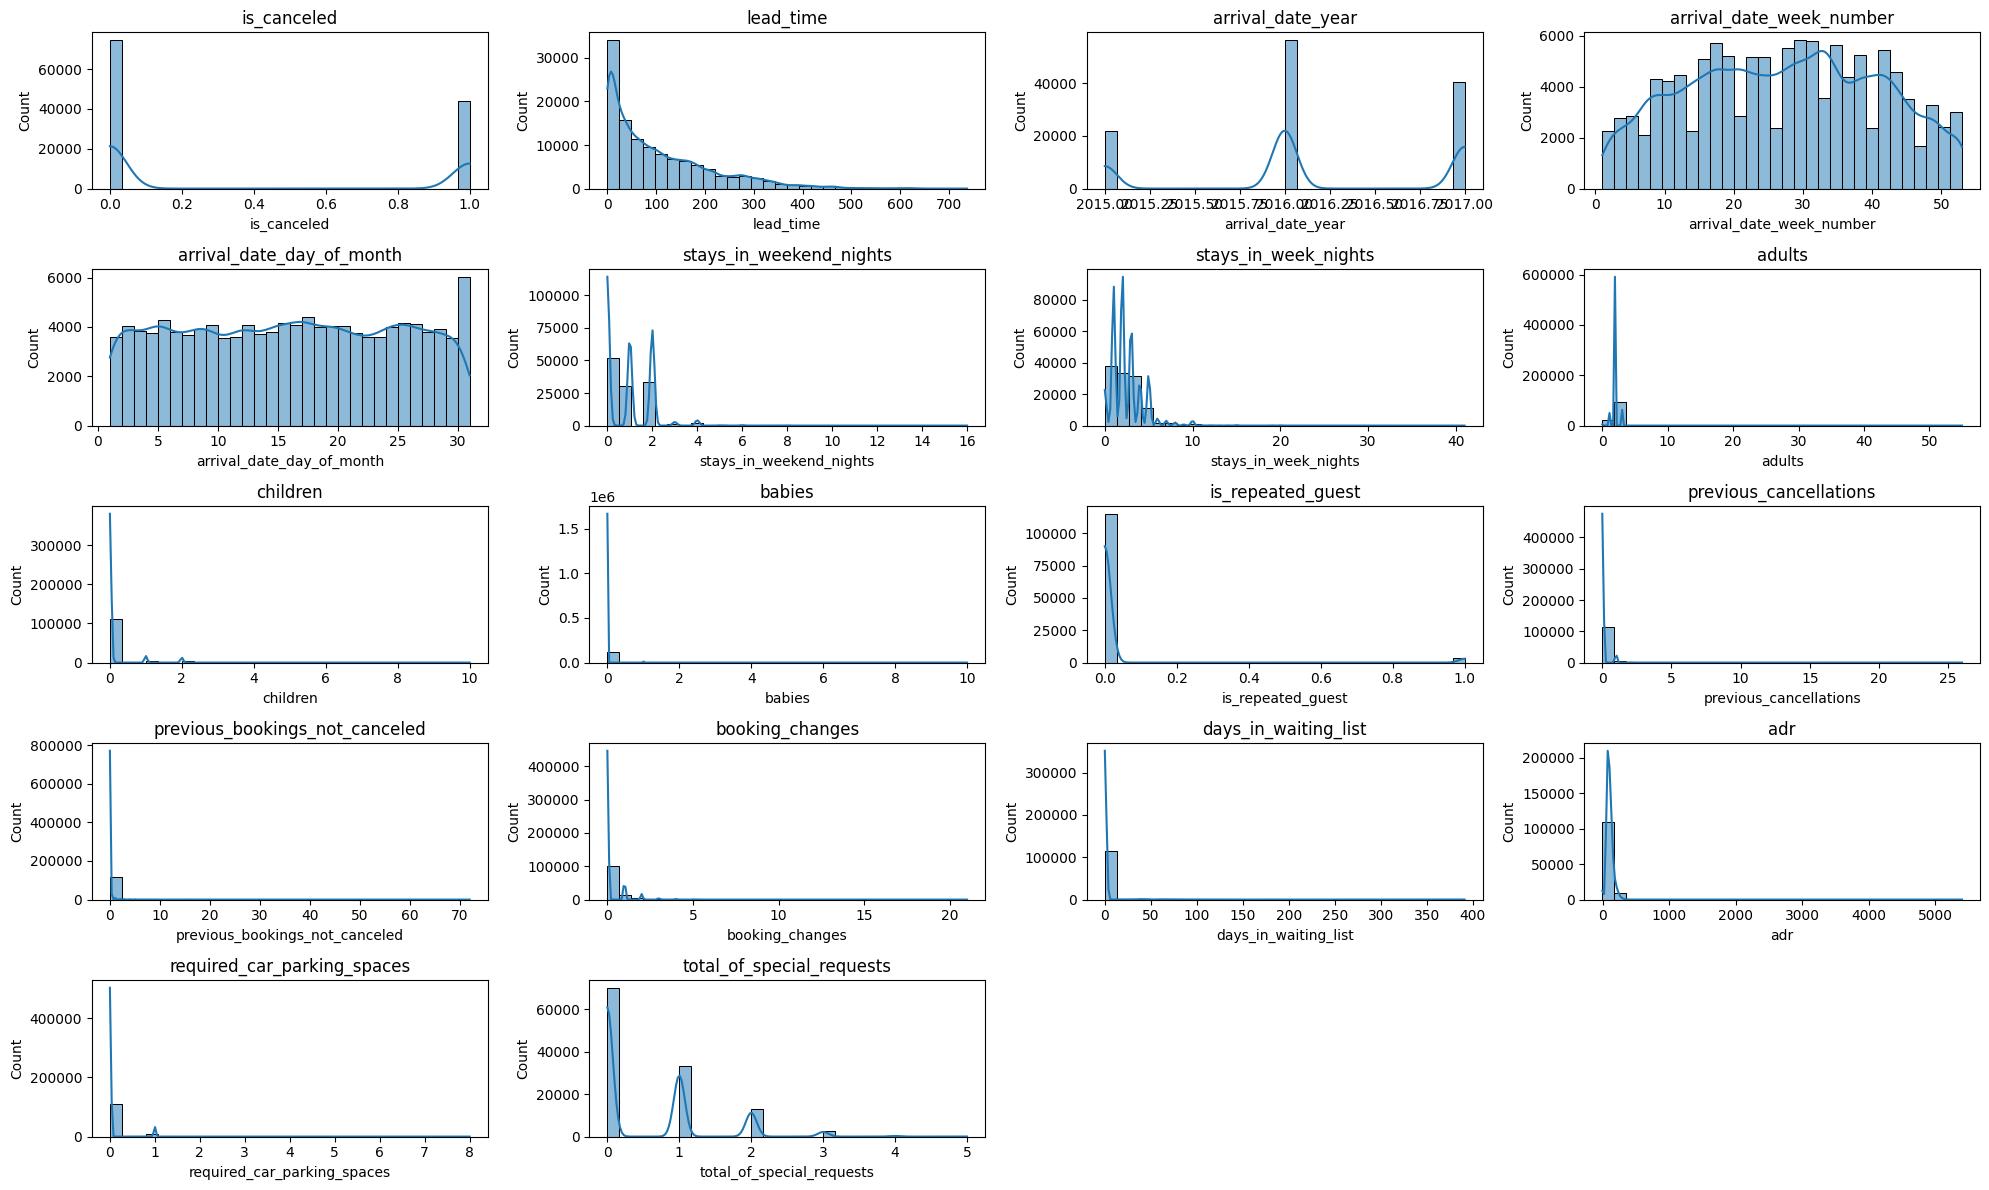

In [12]:
numerical_cols = df.select_dtypes(include="number").columns

# Decide subplot grid size
n_cols = 4
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))

axes = axes.flatten()  # convert to 1D for easy indexing

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], ax=axes[i], kde=True, bins=30)
    axes[i].set_title(col)

# Turn off any unused axes
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

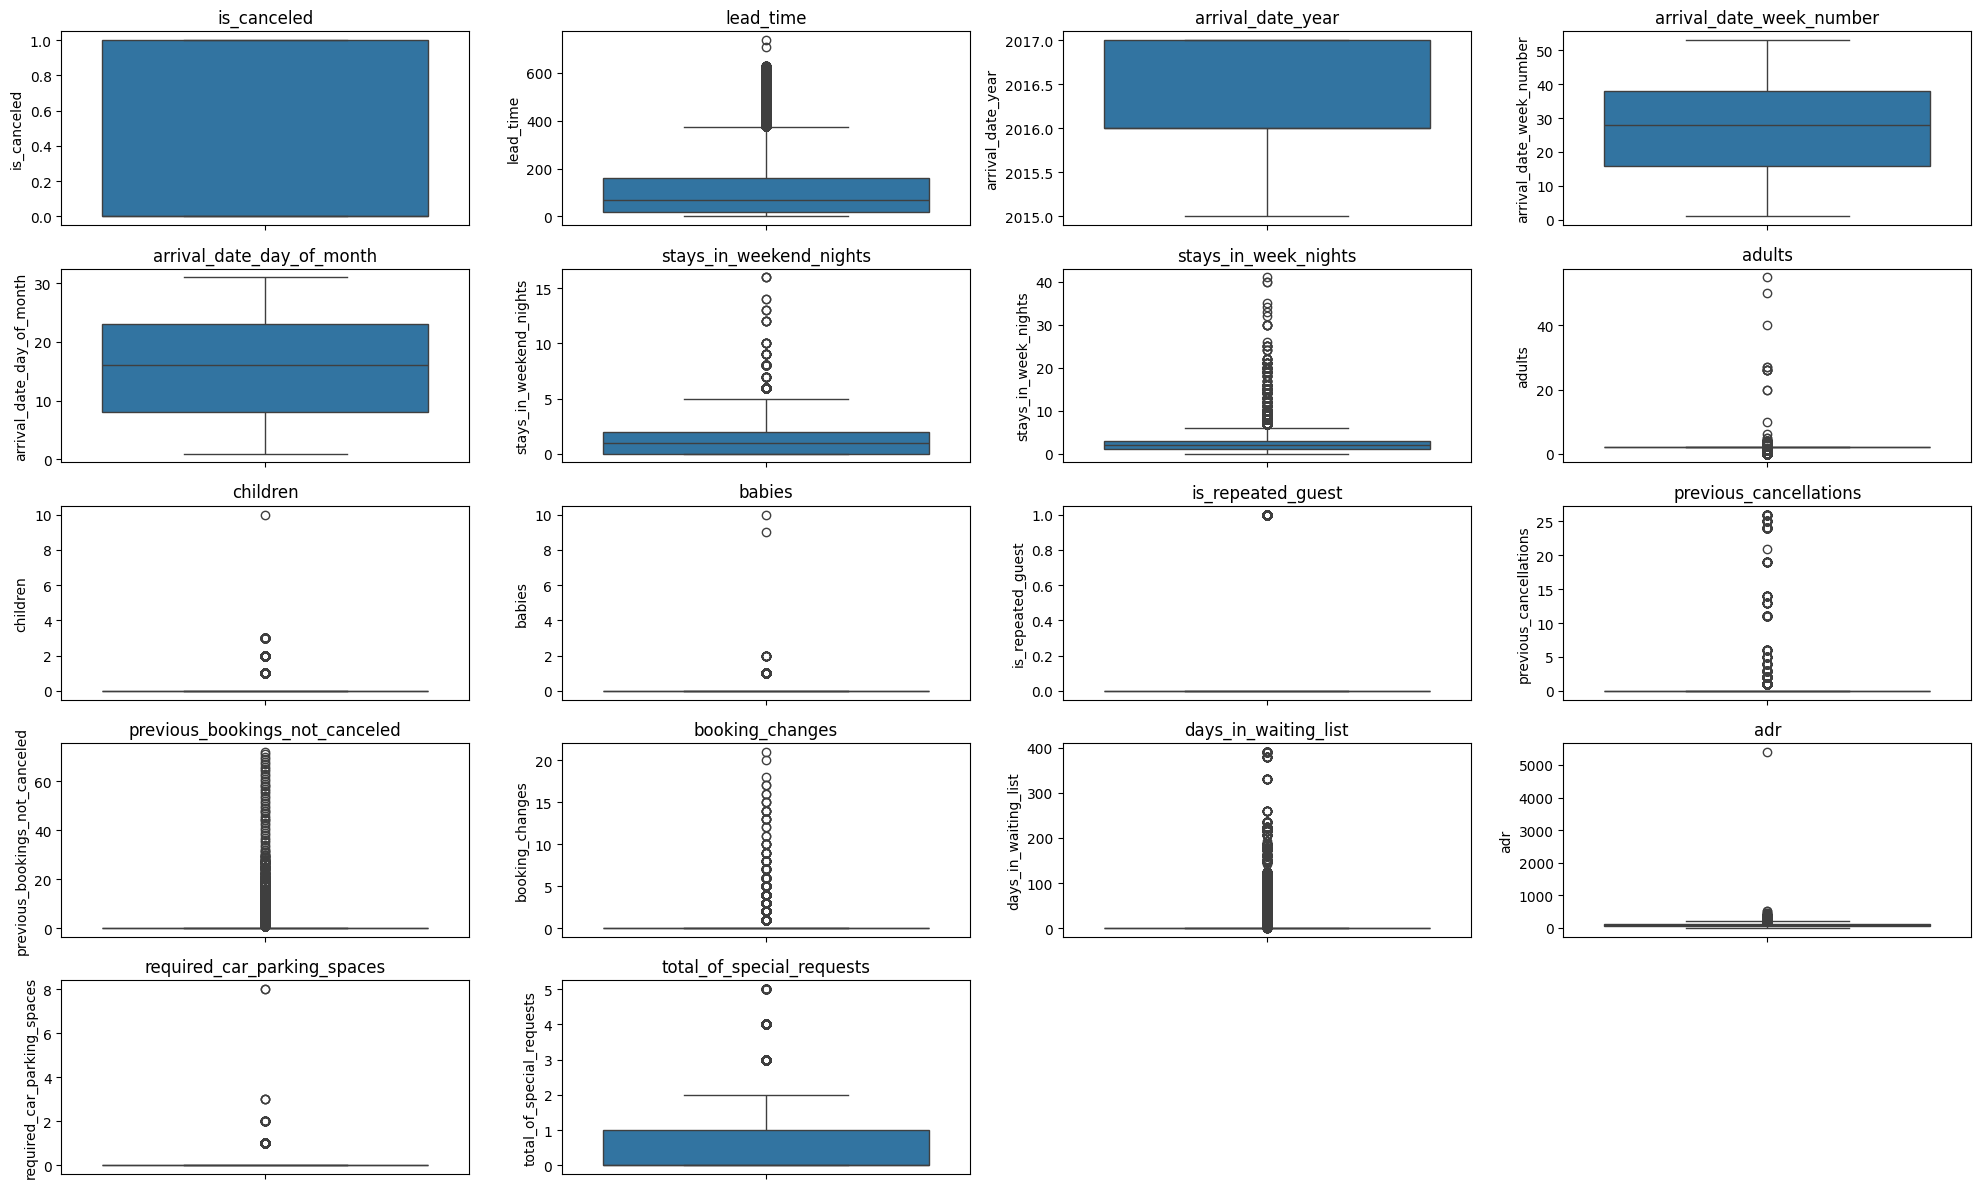

In [13]:
numerical_cols = df.select_dtypes(include="number").columns

# Decide subplot grid size
n_cols = 4
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))

axes = axes.flatten()  # convert to 1D for easy indexing

for i, col in enumerate(numerical_cols):
    sns.boxplot(df[col], ax=axes[i])
    axes[i].set_title(col)

# Turn off any unused axes
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

### Outlier Treatment

In [14]:
df = df[df["adr"] < 5000]  
df = df[df["lead_time"] <= 365]     # 1 year lead time
df = df[df["days_in_waiting_list"] <= 180]      # 6 months waiting period

## Data Analysis and Visualization

is_canceled
0    0.636989
1    0.363011
Name: proportion, dtype: float64


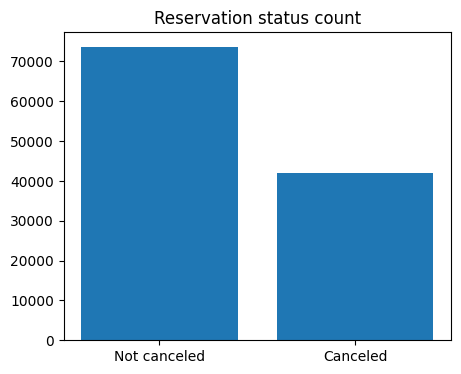

In [15]:
cancelled_perc = df['is_canceled'].value_counts(normalize = True)
print(cancelled_perc)

plt.figure(figsize = (5,4))
plt.title('Reservation status count')
plt.bar(['Not canceled','Canceled'],df['is_canceled'].value_counts())
plt.show()

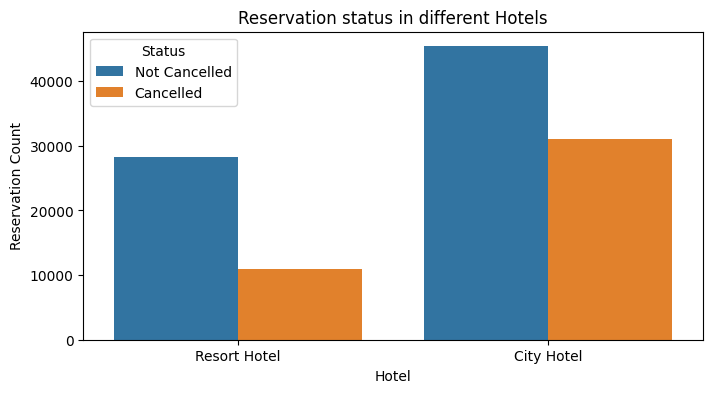

In [16]:
fig, ax = plt.subplots(figsize=(8,4))
sns.countplot(x="hotel", data=df, hue="is_canceled", ax=ax)
ax.set_title("Reservation status in different Hotels")
ax.set_xlabel("Hotel")
ax.set_ylabel("Reservation Count")
ax.legend(title="Status", labels=["Not Cancelled", "Cancelled"], loc="upper left")

In [17]:
resort_hotel = df[df["hotel"] == "Resort Hotel"]
resort_hotel["is_canceled"].value_counts(normalize=True)

is_canceled
0    0.72235
1    0.27765
Name: proportion, dtype: float64

In [18]:
city_hotel = df[df["hotel"] == "City Hotel"]
city_hotel["is_canceled"].value_counts(normalize=True)

is_canceled
0    0.59328
1    0.40672
Name: proportion, dtype: float64

City Hotel has higher cancellation rate

In [19]:
resort_hotel_adr = resort_hotel.groupby("reservation_status_date")["adr"].mean()
city_hotel_adr = city_hotel.groupby("reservation_status_date")["adr"].mean()

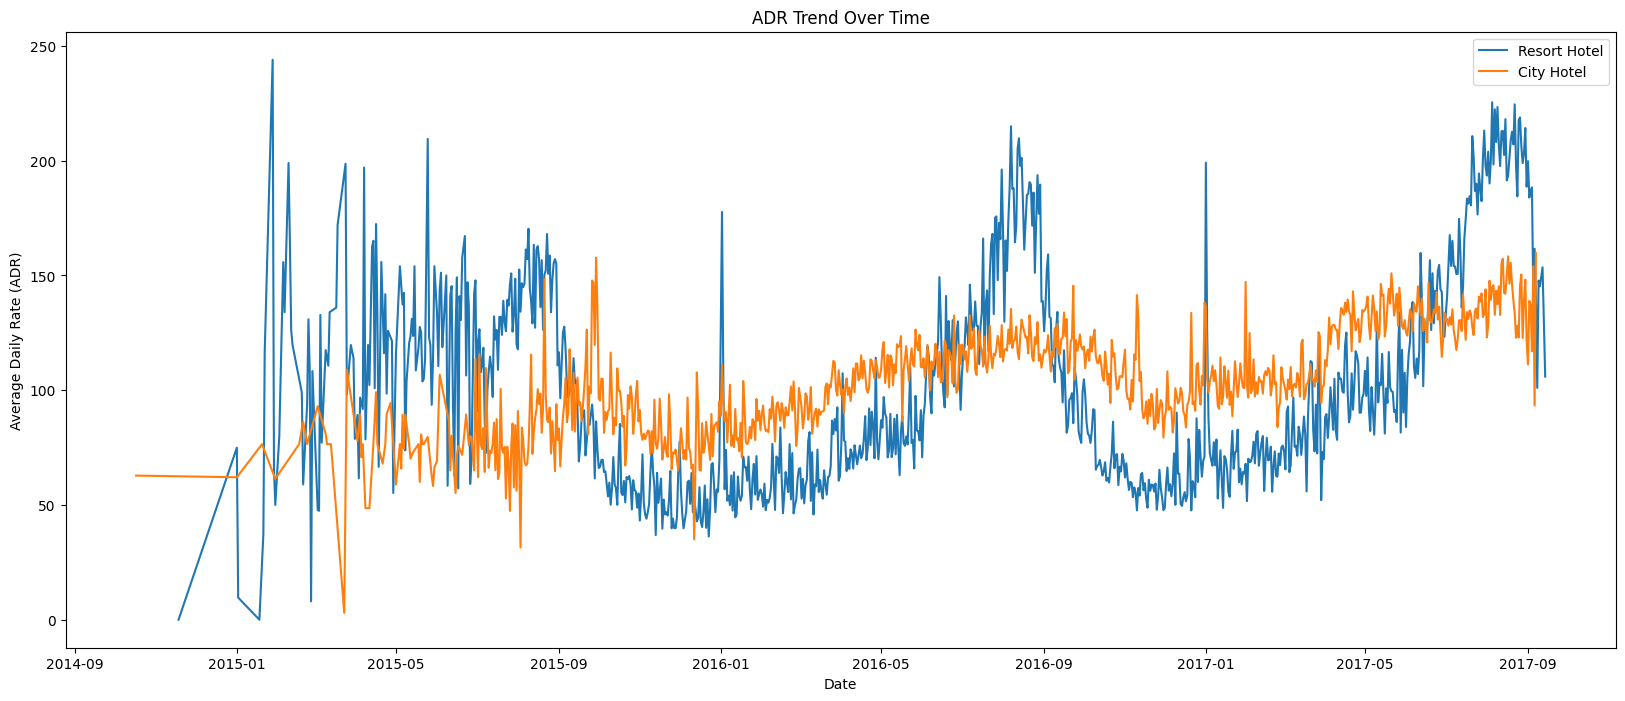

In [20]:
fig, ax = plt.subplots(figsize=(20,8))
ax.plot(resort_hotel_adr.index, resort_hotel_adr, label="Resort Hotel")
ax.plot(city_hotel_adr.index, city_hotel_adr, label="City Hotel")
ax.set_title("ADR Trend Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Average Daily Rate (ADR)")
ax.legend()
plt.show()


In [21]:
df.groupby('hotel')["adr"].mean()

hotel
City Hotel      106.166242
Resort Hotel     95.703876
Name: adr, dtype: float64

In [22]:
df["month"] = df["reservation_status_date"].dt.month

Text(0.5, 1.0, 'Reservation Status per month')

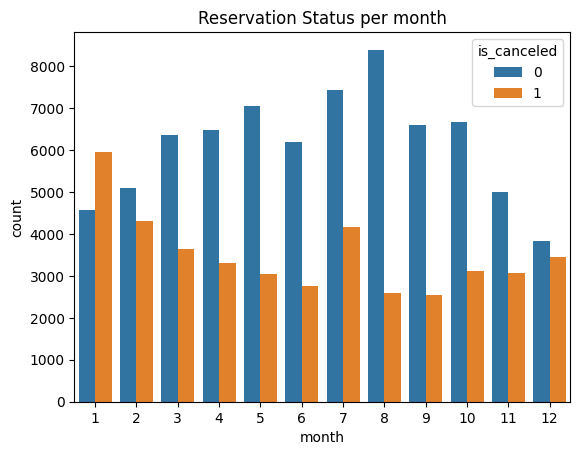

In [23]:
sns.countplot(x="month", data=df, hue="is_canceled")
plt.title("Reservation Status per month")

Text(0.5, 1.0, 'ADR per month for cancelled status')

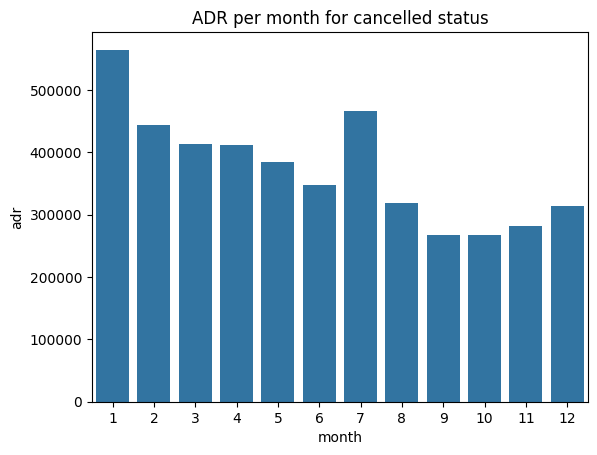

In [24]:
sns.barplot(x="month", y="adr", data=df[df['is_canceled'] == 1].groupby('month')[['adr']].sum().reset_index())
plt.title("ADR per month for cancelled status")

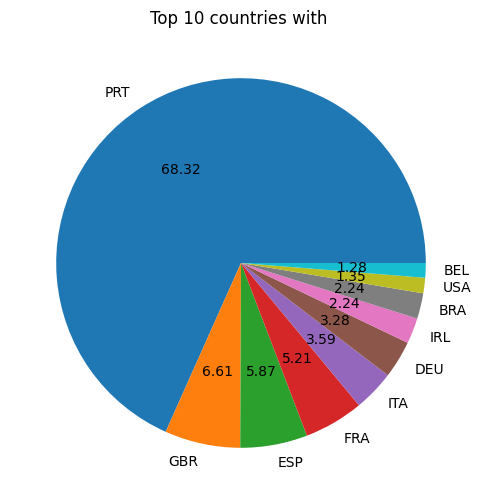

In [25]:
df_cancelled = df[df["is_canceled"] == 1]
top_10_country_cancelled = df_cancelled["country"].value_counts().head(10)
plt.figure(figsize=(6,6))
plt.pie(top_10_country_cancelled, autopct="%.2f", labels=top_10_country_cancelled.index)
plt.title("Top 10 countries with ");

In [26]:
df['market_segment'].value_counts()

market_segment
Online TA        56386
Offline TA/TO    23050
Groups           17648
Direct           12443
Corporate         5111
Complementary      733
Aviation           237
Name: count, dtype: int64

In [27]:
df['market_segment'].value_counts(normalize = True)

market_segment
Online TA        0.487734
Offline TA/TO    0.199381
Groups           0.152654
Direct           0.107631
Corporate        0.044210
Complementary    0.006340
Aviation         0.002050
Name: proportion, dtype: float64

In [28]:
df_cancelled['market_segment'].value_counts(normalize = True)

market_segment
Online TA        0.493817
Groups           0.247814
Offline TA/TO    0.186003
Direct           0.045679
Corporate        0.023304
Complementary    0.002145
Aviation         0.001239
Name: proportion, dtype: float64

<Axes: title={'center': 'Cancellation rates by Market Segment'}, ylabel='market_segment'>

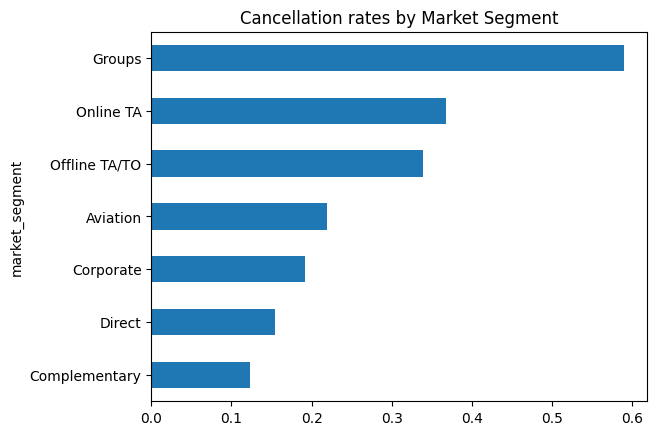

In [29]:
(df.groupby("market_segment")["is_canceled"].sum() / df.groupby("market_segment")["is_canceled"].count()).sort_values().plot(kind="barh", title="Cancellation rates by Market Segment")

<Axes: xlabel='month', ylabel='count'>

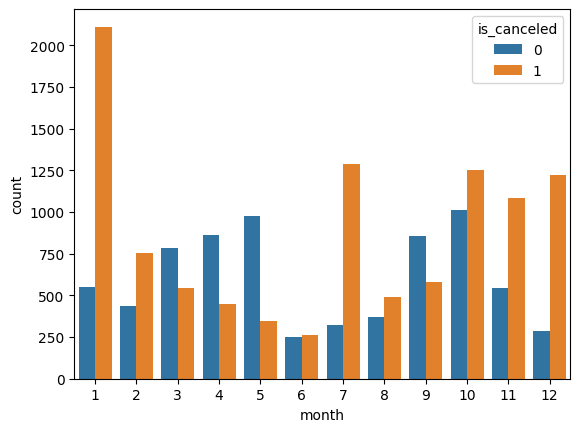

In [30]:
df_groups_market_segment = df[df["market_segment"] == "Groups"]

sns.countplot(x="month", data=df_groups_market_segment, hue="is_canceled")

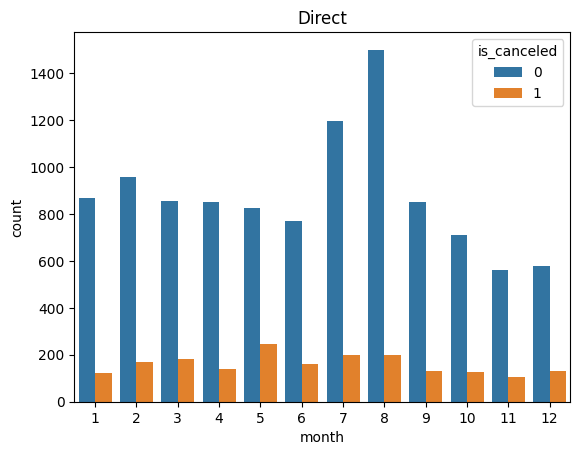

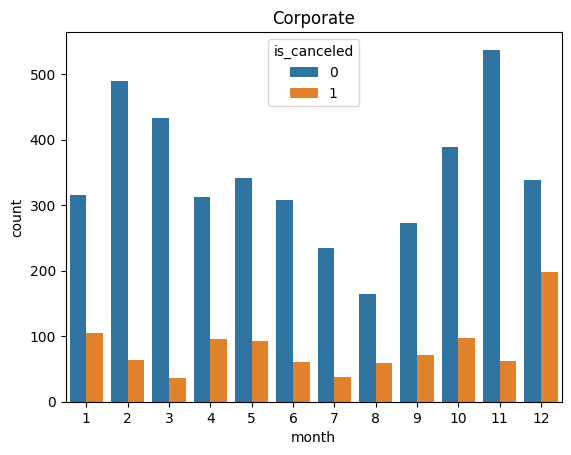

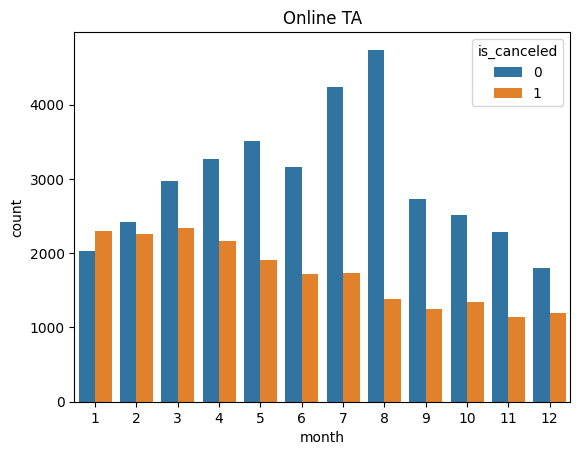

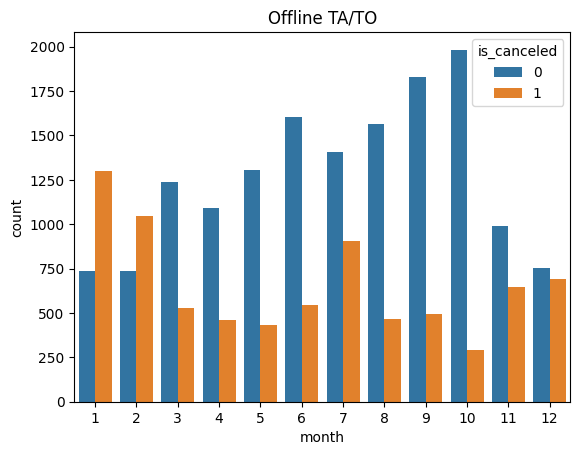

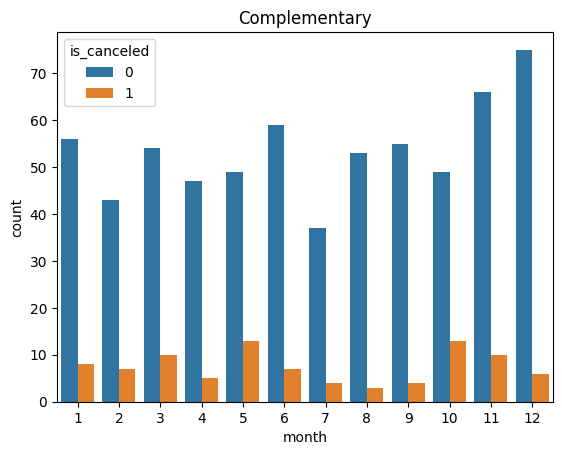

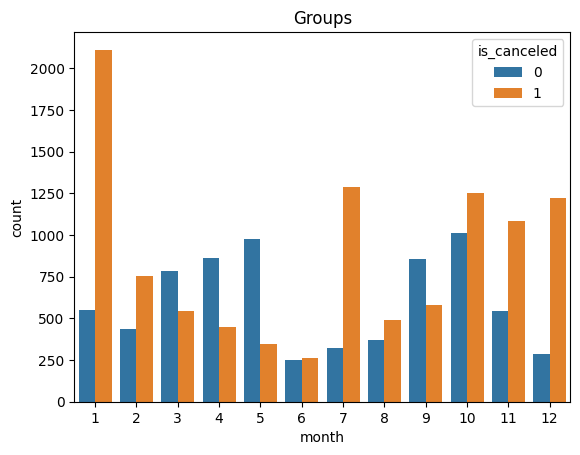

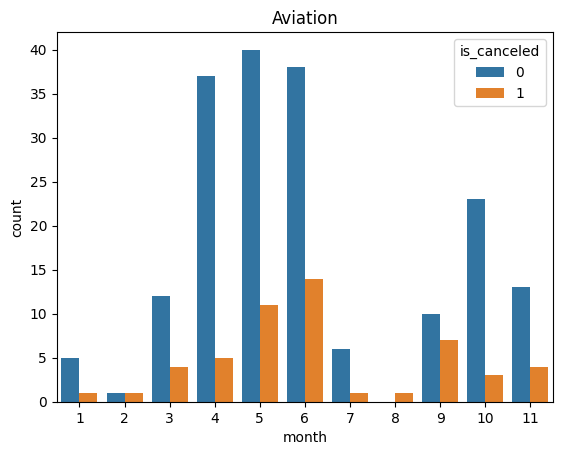

In [31]:

for counter in df["market_segment"].unique():
    plt.figure()
    df_temp = df[df["market_segment"] == counter]
    sns.countplot(x="month", data=df_temp, hue="is_canceled")
    plt.title(counter)

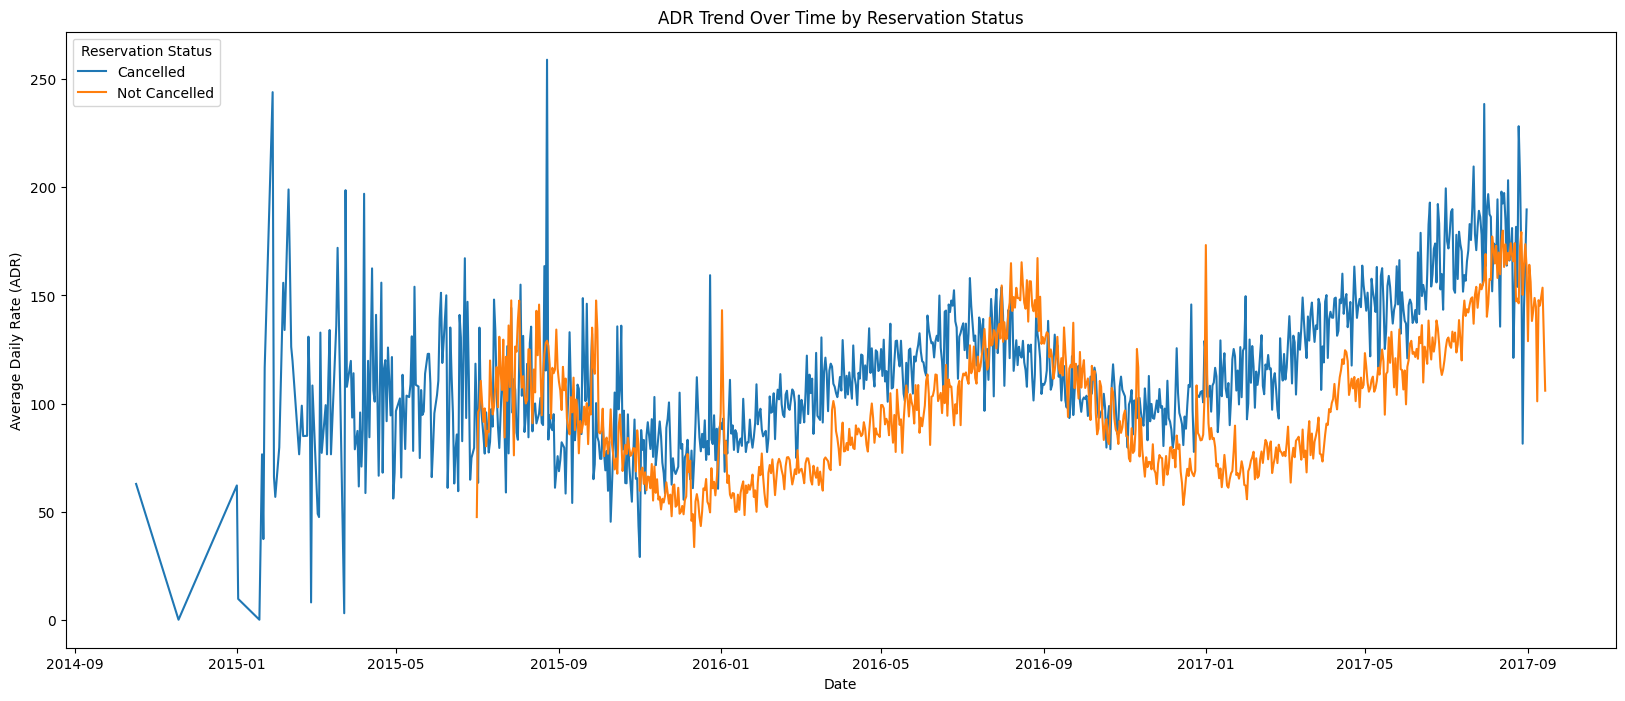

In [32]:
df_cancelled_adr = df_cancelled.groupby("reservation_status_date")["adr"].mean()
df_not_cancelled = df[df["is_canceled"] == 0]
df_not_cancelled_adr = df_not_cancelled.groupby("reservation_status_date")["adr"].mean()

fig, ax = plt.subplots(figsize=(20,8))
ax.plot(df_cancelled_adr.index, df_cancelled_adr, label="Cancelled")
ax.plot(df_not_cancelled_adr.index, df_not_cancelled_adr, label="Not Cancelled")
ax.set_title("ADR Trend Over Time by Reservation Status")
ax.set_xlabel("Date")
ax.set_ylabel("Average Daily Rate (ADR)")
ax.legend(title="Reservation Status")
plt.show()

### Lead Time

In [33]:
df.groupby("is_canceled")["lead_time"].mean()

is_canceled
0     75.363968
1    129.288560
Name: lead_time, dtype: float64

Cancelled reservations do have a greater lead time

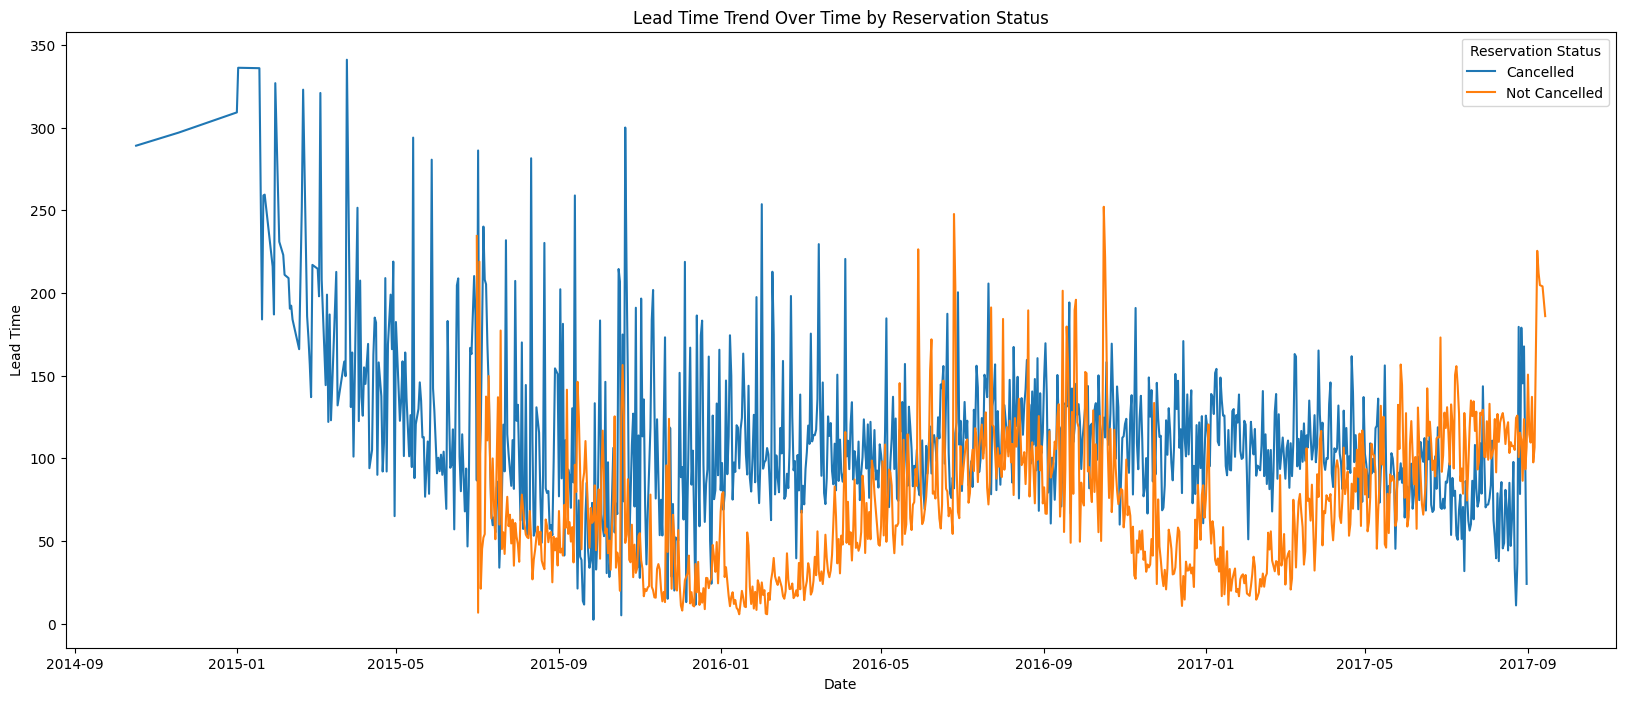

In [34]:
df_cancelled_lead_time = df_cancelled.groupby("reservation_status_date")["lead_time"].mean()
df_not_cancelled = df[df["is_canceled"] == 0]
df_not_cancelled_lead_time = df_not_cancelled.groupby("reservation_status_date")["lead_time"].mean()

fig, ax = plt.subplots(figsize=(20,8))
ax.plot(df_cancelled_lead_time.index, df_cancelled_lead_time, label="Cancelled")
ax.plot(df_not_cancelled_lead_time.index, df_not_cancelled_lead_time, label="Not Cancelled")
ax.set_title("Lead Time Trend Over Time by Reservation Status")
ax.set_xlabel("Date")
ax.set_ylabel("Lead Time")
ax.legend(title="Reservation Status")
plt.show()

In [35]:
df.groupby("hotel")["lead_time"].mean()

hotel
City Hotel      97.560190
Resort Hotel    89.820536
Name: lead_time, dtype: float64

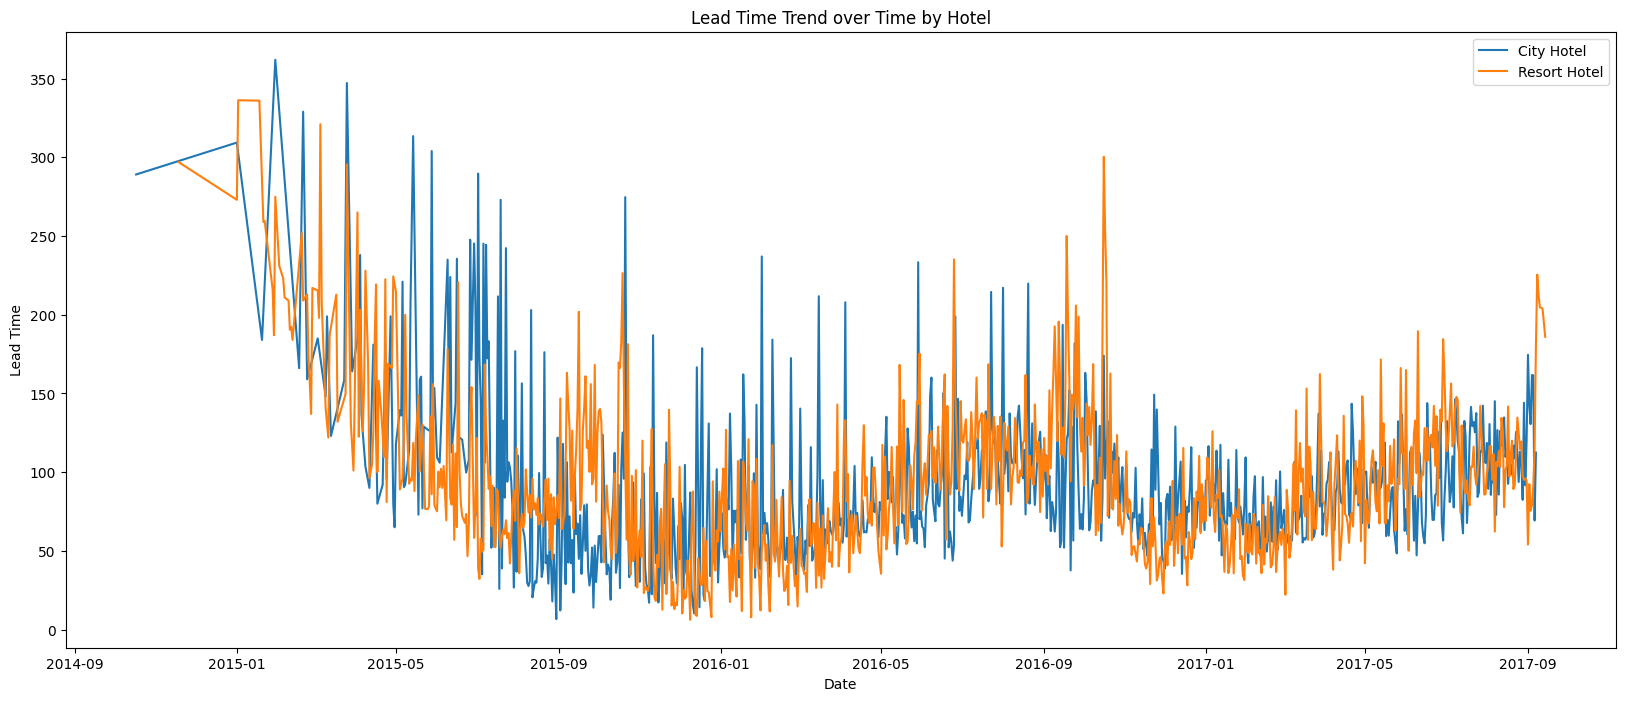

In [36]:
city_hotel_lead_time = city_hotel.groupby("reservation_status_date")["lead_time"].mean()
resort_hotel_lead_time = resort_hotel.groupby("reservation_status_date")["lead_time"].mean()

fig, ax = plt.subplots(figsize=(20,8))
ax.plot(city_hotel_lead_time, label="City Hotel")
ax.plot(resort_hotel_lead_time, label="Resort Hotel")
ax.set_title("Lead Time Trend over Time by Hotel")
ax.set_xlabel("Date")
ax.set_ylabel("Lead Time")
ax.legend()

Text(0.5, 1.0, 'Lead Time over Month by Hotel')

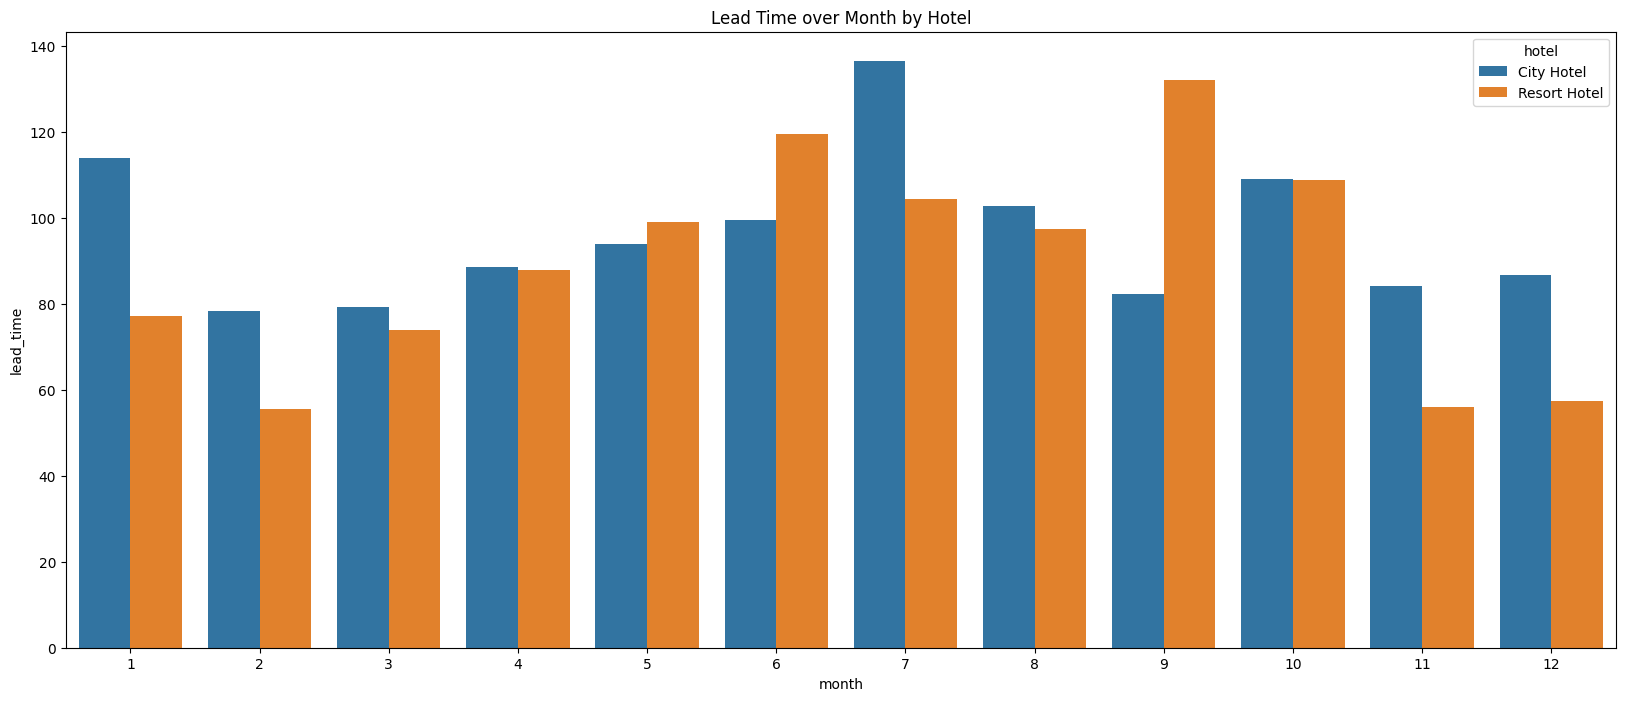

In [37]:

fig, ax = plt.subplots(figsize=(20,8))
sns.barplot(x="month", y="lead_time", data=df.groupby(["month","hotel"])["lead_time"].mean().reset_index(), hue="hotel", ax=ax)
ax.set_title("Lead Time over Month by Hotel")

### Waiting Period

In [38]:
df.groupby("is_canceled")["days_in_waiting_list"].mean()

is_canceled
0    1.167529
1    2.807944
Name: days_in_waiting_list, dtype: float64

In [39]:
df.groupby("hotel")["days_in_waiting_list"].mean()

hotel
City Hotel      2.394596
Resort Hotel    0.529579
Name: days_in_waiting_list, dtype: float64

Text(0.5, 1.0, 'Waiting Period over Month by Hotel')

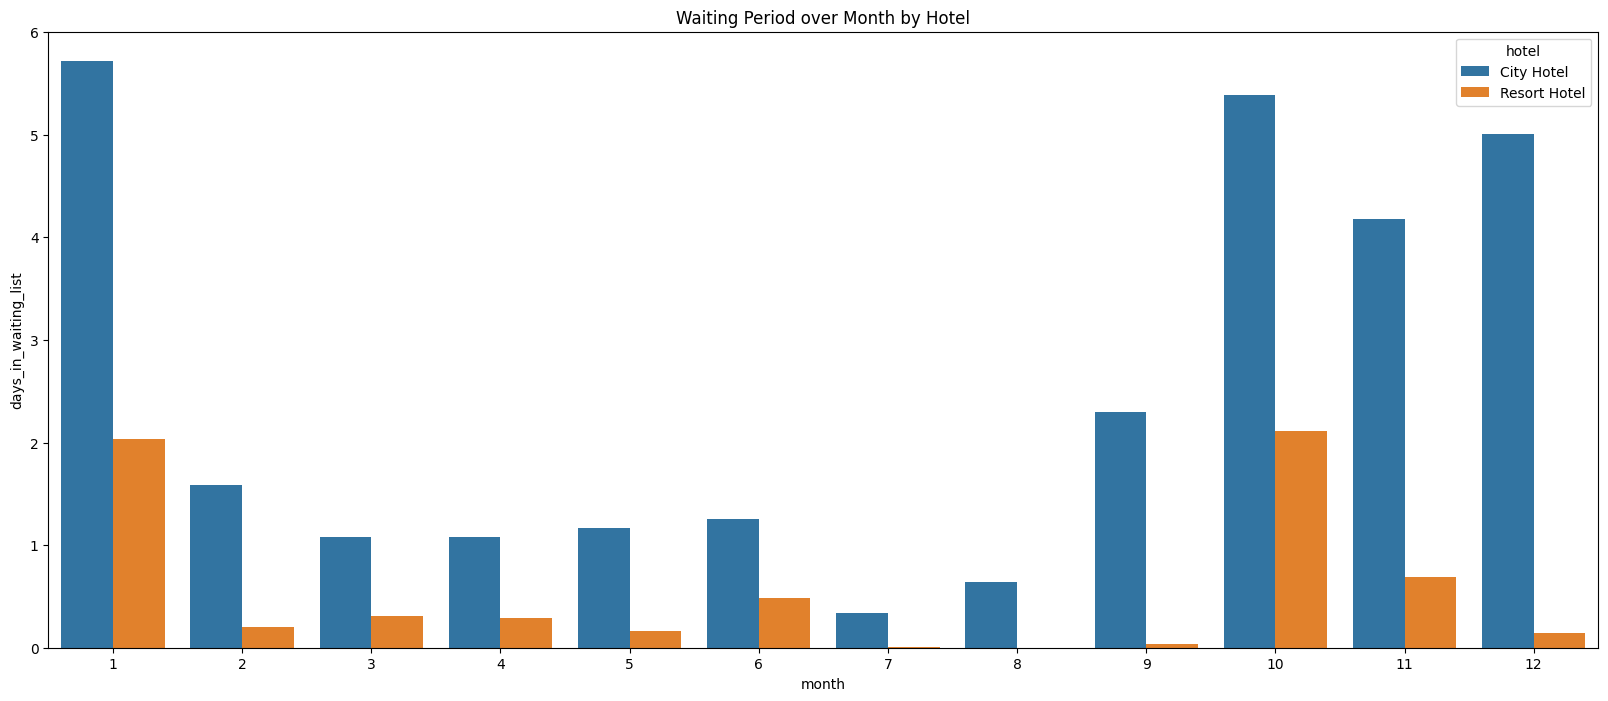

In [40]:
fig, ax = plt.subplots(figsize=(20,8))
sns.barplot(x="month", y="days_in_waiting_list", data=df.groupby(["month","hotel"])["days_in_waiting_list"].mean().reset_index(), hue="hotel", ax=ax)
ax.set_title("Waiting Period over Month by Hotel")

City Hotel has higher waiting period for reservations

Text(0.5, 1.0, 'Waiting Period over Month by ReservationStatus')

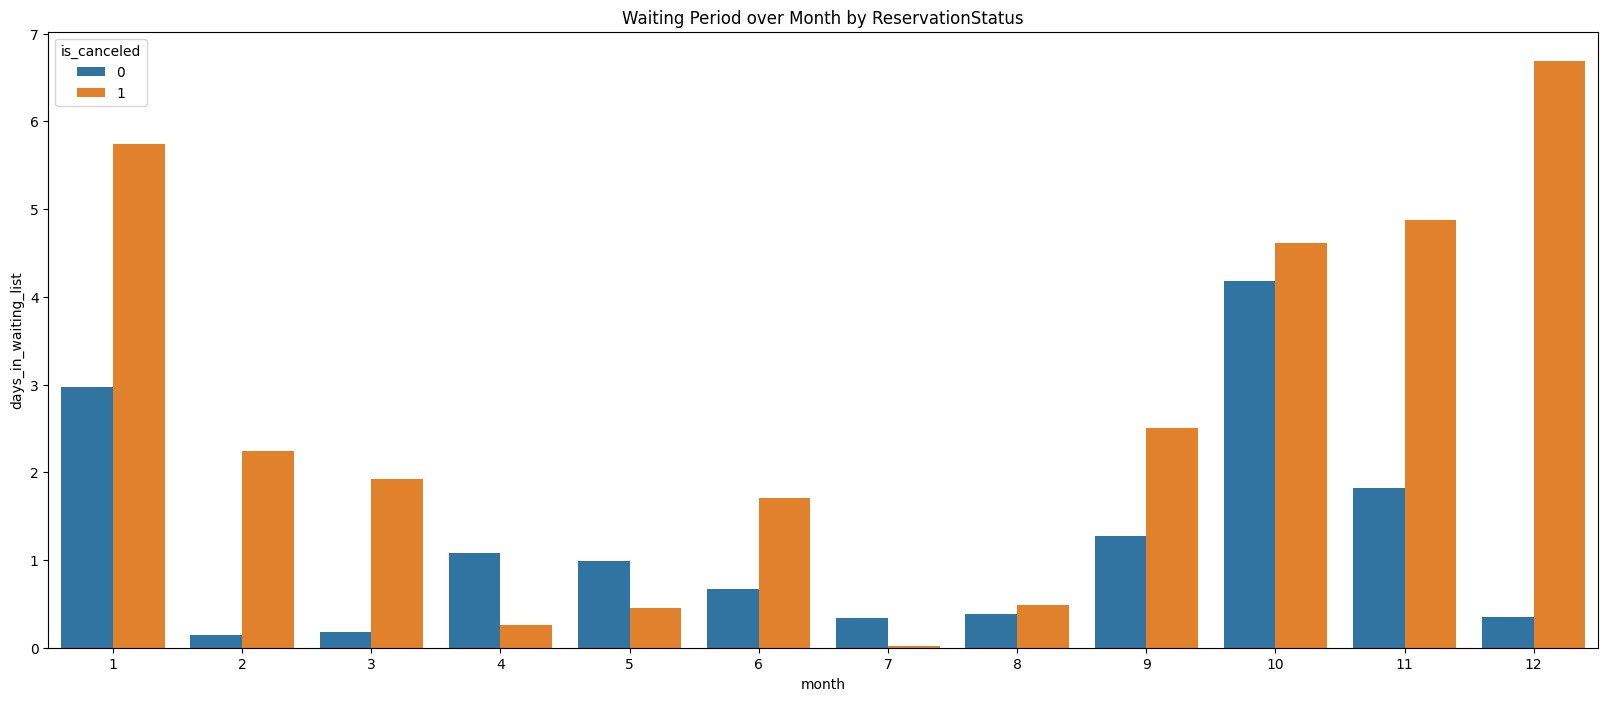

In [41]:
fig, ax = plt.subplots(figsize=(20,8))
sns.barplot(x="month", y="days_in_waiting_list", data=df.groupby(["month","is_canceled"])["days_in_waiting_list"].mean().reset_index(), hue="is_canceled", ax=ax)
ax.set_title("Waiting Period over Month by ReservationStatus")

### Reserved Room / Assigned Room

In [42]:
df_room = df.copy()
df_room["same_room"] = (df_room["reserved_room_type"] == df_room["assigned_room_type"]).astype(int)
df_room.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,month,same_room
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01,7,1
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,7,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,7,1
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,0,Transient,98.0,0,1,Check-Out,2015-07-03,7,1
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,0,Transient,98.0,0,1,Check-Out,2015-07-03,7,1


In [43]:
df_room["same_room"].value_counts(normalize=True)

same_room
1    0.873997
0    0.126003
Name: proportion, dtype: float64

In [44]:
df_room.groupby("same_room")["is_canceled"].sum() / df_room["same_room"].value_counts()

same_room
0    0.052585
1    0.407765
dtype: float64

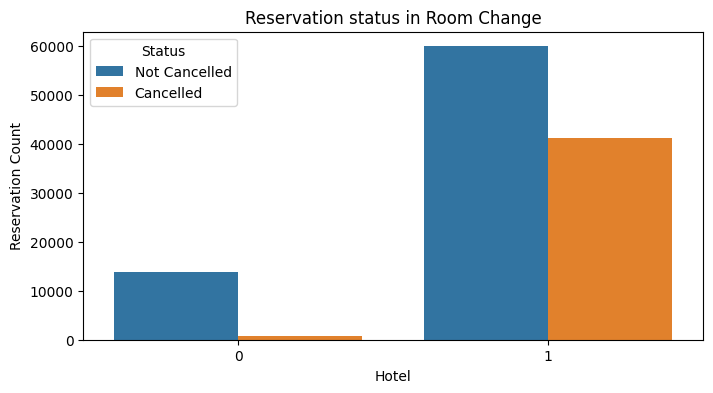

In [45]:
fig, ax = plt.subplots(figsize=(8,4))
sns.countplot(x="same_room", data=df_room, hue="is_canceled", ax=ax)
ax.set_title("Reservation status in Room Change")
ax.set_xlabel("Hotel")
ax.set_ylabel("Reservation Count")
ax.legend(title="Status", labels=["Not Cancelled", "Cancelled"], loc="upper left")